<a href="https://colab.research.google.com/github/kondratyukkatya9-ML/ML_home_work/blob/main/Copy_of_HW_2_1_%D0%9F%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B0_%D0%BB%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97_%D0%B7%D0%B0_%D0%BE%D0%B4%D0%BD%D0%BE%D1%8E_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D1%8E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [2]:
import pandas as pd
medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [3]:
import numpy as np

In [4]:
X = non_smoker_df[['age']].values
y = non_smoker_df['charges'].values

In [5]:
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

In [6]:
def normal_equations(X,y):
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [7]:
theta = normal_equations(X_with_intercept, y) #МНК
print("bias:", theta[0])
print("вага age:", theta[1])

bias: -2091.4205565650805
вага age: 267.2489128311998


In [16]:
print(X[:, 0].min(), X[:, 0].max())
print(y.min(), y.max())

18 64
1121.8739 36910.60803


In [24]:
predictions_mnk = X_with_intercept @ theta
mse_mnk = np.mean((predictions_mnk - y)**2)
print(f"MSE МНК: {mse_mnk:.2f}")

MSE МНК: 21738960.02


In [28]:
# Градієнтний спуск
def full_batch_gradient_descent(X, y, lr=0.00001, epochs=50000):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(np.mean(error**2))   #
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

m, b, errors = full_batch_gradient_descent(X, y, lr=0.00001, epochs=50000)
predictions_fbgd = m * X[:, 0] + b

m, b

(np.float64(225.10031594568287), np.float64(-219.44639872346897))

In [26]:
for lr in [1e-4, 1e-5, 1e-6]:
    m, b, errors = full_batch_gradient_descent(X, y, lr=lr, epochs=5000)
    mse = errors[-1] if errors else 'N/A'
    print(f"lr={lr}: m={m:.4f}, b={b:.4f}, final MSE={mse}")

lr=0.0001: m=225.1004, b=-219.4486, final MSE=22135919.565590706
lr=1e-05: m=220.5792, b=-18.6460, final MSE=22225629.368304614
lr=1e-06: m=220.1012, b=2.5824, final MSE=22235646.8784204


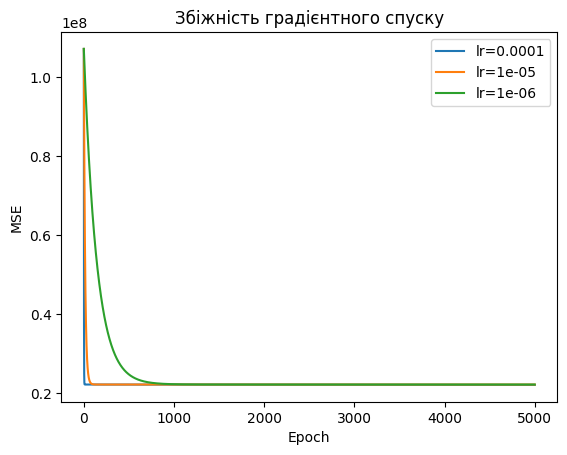

In [27]:
import matplotlib.pyplot as plt

for lr in [1e-4, 1e-5, 1e-6]:
    m, b, errors = full_batch_gradient_descent(X, y, lr=lr, epochs=5000)
    plt.plot(errors, label=f'lr={lr}')

plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Збіжність градієнтного спуску')
plt.show()

In [30]:
!pip install scikit-learn --quiet

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
lin_reg = LinearRegression()

In [33]:
lin_reg.fit(X, y)

LinearRegression()

In [34]:
lin_reg.coef_, lin_reg.intercept_

(array([267.24891283]), np.float64(-2091.4205565650864))

In [35]:
predictions_sklearn = lin_reg.predict(X)

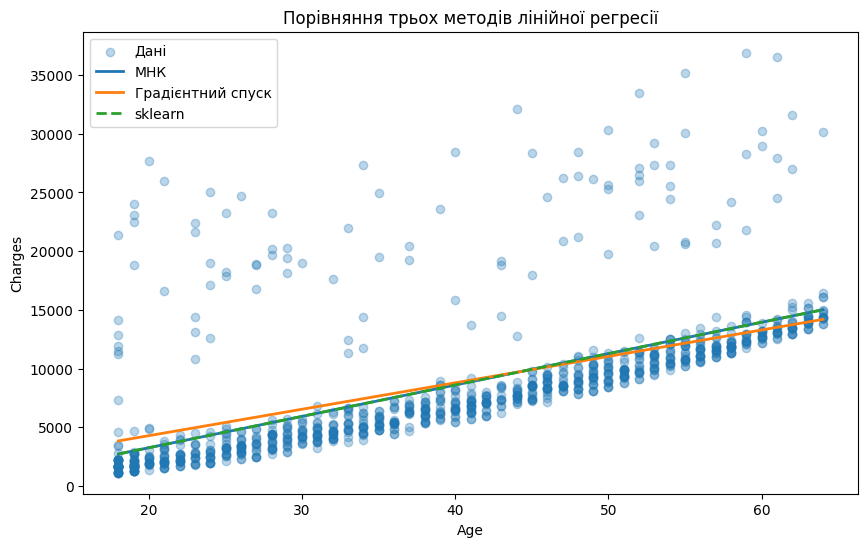

In [37]:
plt.figure(figsize=(10, 6))

# Scatter — реальні дані
plt.scatter(X[:, 0], y, alpha=0.3, label='Дані')

# Сортуємо X
sort_idx = X[:, 0].argsort()
X_sorted = X[:, 0][sort_idx]

# 3 лінії регресії
plt.plot(X_sorted, predictions_mnk[sort_idx], label='МНК', linewidth=2)
plt.plot(X_sorted, predictions_fbgd[sort_idx], label='Градієнтний спуск', linewidth=2)
plt.plot(X_sorted, predictions_sklearn[sort_idx], label='sklearn', linewidth=2, linestyle='--')

plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.title('Порівняння трьох методів лінійної регресії')
plt.show()

In [41]:
# Коефіцієнти:
print("МНК:", theta[1], theta[0])
print("Градієнтний спуск:", m, b)
print("sklearn:", lin_reg.coef_[0], lin_reg.intercept_)

МНК: 267.2489128311998 -2091.4205565650805
Градієнтний спуск: 225.10031594568287 -219.44639872346897
sklearn: 267.2489128311997 -2091.4205565650864


In [42]:
from sklearn.metrics import mean_squared_error

rmse_mnk = np.sqrt(mean_squared_error(y, predictions_mnk))
rmse_fbgd = np.sqrt(mean_squared_error(y, predictions_fbgd))
rmse_sklearn = np.sqrt(mean_squared_error(y, predictions_sklearn))

print(f"RMSE МНК: {rmse_mnk:.2f}")
print(f"RMSE Градієнтний спуск: {rmse_fbgd:.2f}")
print(f"RMSE sklearn: {rmse_sklearn:.2f}")

RMSE МНК: 4662.51
RMSE Градієнтний спуск: 4704.88
RMSE sklearn: 4662.51


Моделі МНК і sklearn ідентичні, відріхняються тільк дані моделі з градієнтним спуском. На графіку залежності МSE від кількості епох, ми бачимо, що пісдя 1000 епох, MSE вже мало змінюється, очевидно, що GD "застряг", тому, що коефіцієнти різні за величиною і lr для b є занадто малим, тоді як m вчиться набагато швидше. очевидно коефіцієнти потребують нормаліації

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [43]:
smoker_df = medical_df[medical_df.smoker == 'yes']

In [48]:
X1 = smoker_df[['age']].values
y1 = smoker_df['charges'].values

In [49]:
lin_reg_smoker = LinearRegression()


In [50]:
lin_reg_smoker.fit(X1, y1)

LinearRegression()

In [51]:
lin_reg_smoker.coef_, lin_reg_smoker.intercept_

(array([305.23760211]), np.float64(20294.128126915966))

In [54]:
predictions_smoker = lin_reg_smoker.predict(X)

In [55]:
# RMSE
rmse_smoker = np.sqrt(mean_squared_error(y1, predictions_smoker))
print(f"RMSE: {rmse_smoker:.2f}")

RMSE: 10711.00


In [56]:
print(X1[:, 0].min(), X1[:, 0].max())
print(y1.min(), y1.max())

18 64
12829.4551 63770.42801


In [58]:
print(f"Mean charges: {y1.mean():.2f}")
print(f"RMSE / Mean: {rmse_smoker / y1.mean() * 100:.1f}%")

Mean charges: 32050.23
RMSE / Mean: 33.4%


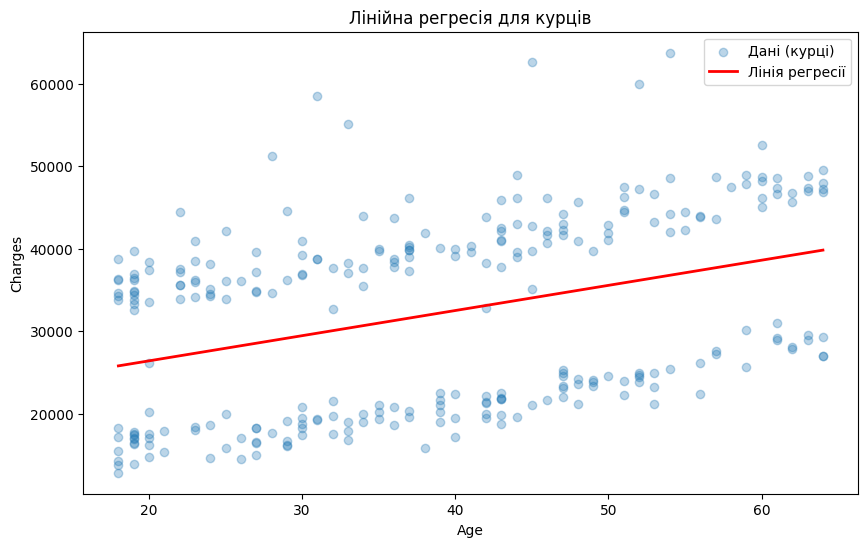

In [57]:
plt.figure(figsize=(10, 6))
plt.scatter(X1, y1, alpha=0.3, label='Дані (курці)')
plt.plot(np.sort(X1[:, 0]), predictions_smoker[X1[:, 0].argsort()],
         color='red', linewidth=2, label='Лінія регресії')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.title('Лінійна регресія для курців')
plt.show()

Модель лише на цих даних не може бути точною через великий дозкид точок, що видно на графіку та підтверджується даними: RMSE = 10,711, що складає 33.4% від середнього значення charges. Така модель буде дуже неточно.